# Bayesian Causal Forest for HTE — stochtree implementation

**Model**: BCF for binary outcomes (probit link) following Hahn, Murray & Carvalho (2020).  
Baseline risk $\mu(X, \hat{\pi})$ and treatment effect surface $\tau(X)$ are modelled with separate BART components using a purpose-built BCF sampler (not NUTS), avoiding the joint non-identifiability problems of a PyMC implementation.

$$Y_i \sim \text{Bernoulli}\left(\Phi\left(\mu(x_i, \hat{\pi}_i) + \tau(x_i) \cdot T_i\right)\right)$$

- $\mu(x_i, \hat{\pi}_i)$ — **prognostic function**: baseline risk on the probit scale, adjusted for targeted selection via the logit propensity score $\hat{\pi}_i$
- $\tau(x_i)$ — **treatment effect function**: CATE on the probit scale; regularised toward zero
- $T_i \in \{0, 1\}$ — treatment indicator
- $\Phi(\cdot)$ — standard normal CDF (probit link)

**Why stochtree instead of PyMC-BART?**

| Issue | PyMC-BART joint model | stochtree BCF |
|---|---|---|
| Sampler | NUTS + PGBART (mismatched) | Purpose-built BCF MCMC |
| Joint identifiability | μ and τ compete; non-identified | Orthogonal updates by design |
| Binary outcome link | `response='constant'` mismatch | Native probit BCF support |
| T in X_tau | Manual exclusion required | Automatically excluded |
| Initialisation | Arbitrary y_latent scaling | Principled zero-centred prior |

## 0. Installation

```bash
pip install stochtree scikit-learn arviz seaborn
```

`stochtree` ships with C++ bindings for the BCF sampler. No R dependency.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from scipy.stats import norm
from scipy.special import expit
from sklearn.tree import DecisionTreeRegressor
import shap
import warnings
warnings.filterwarnings("ignore")

# stochtree: purpose-built BCF sampler
from stochtree import BCFModel, OutcomeModel

rng = np.random.default_rng(123)
output_folder = "ISYE6420/Project/"

## 1. Data Loading and Preparation

In [2]:
dx_name = "asthma"
version = "v7_040226"

cohort = pd.read_csv(f"ISYE6420/Project/data/asthma_weighted_cohort.csv")
print(f"Cohort size: {len(cohort):,}")

Cohort size: 65,417


In [3]:
y_raw         = cohort["outcome"].values
T             = cohort["exposure"].values.astype(int)
follow_up_time = cohort["follow_up_time"].values

# Binary indicator: any exacerbation in follow-up
y_data = (y_raw > 0).astype(float)   # stochtree expects float for BCF

num_exac_pats = y_data.mean()
print(f"Proportion with ≥1 exacerbation: {num_exac_pats:.2%}")
print(f"Treated: {T.mean():.2%}  |  Control: {(1-T).mean():.2%}")

Proportion with ≥1 exacerbation: 5.40%
Treated: 20.71%  |  Control: 79.29%


## 2. Feature Matrices

**Key design decisions vs the original PyMC notebook:**

1. `X_mu` includes logit propensity score — the BCF identification argument requires this to absorb targeted selection bias into the prognostic surface.
2. `X_tau` does **not** include `T` or the propensity score. The treatment indicator is passed separately to `BCFModel.sample()`; stochtree handles the $\tau(x) \cdot T$ product internally. Including T in X_tau would allow tau to split on treatment assignment, breaking causal identification.
3. Both matrices exclude `patid`, `outcome`, `exposure`, `follow_up_time`, `weight`, and `ps_score` from the raw cohort.

In [4]:
# Base covariate matrix (no outcome, no treatment, no admin cols)
drop_cols = ["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"]
X_base = cohort.drop(columns=drop_cols).astype(int)

# Logit-transform propensity scores for mu (stabilises the probit scale)
eps = 1e-6
ps_values = np.clip(cohort["ps_score"], eps, 1 - eps)
logit_ps  = np.log(ps_values / (1 - ps_values))

# --- Prognostic feature matrix: covariates + logit PS ---
X_mu = X_base.copy()
X_mu["logit_ps"] = logit_ps
X_mu = X_mu.values.astype(float)

# --- Treatment effect feature matrix: covariates ONLY (no T, no PS) ---
# T is passed separately; PS is a confounder for baseline risk, not HTE
X_tau = X_base.values.astype(float)

print(f"X_mu shape : {X_mu.shape}")
print(f"X_tau shape: {X_tau.shape}")
print(f"Covariate columns: {list(X_base.columns)}")

X_mu shape : (65417, 38)
X_tau shape: (65417, 37)
Covariate columns: ['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline', 'num_outpatient_event', 'num_er_event', 'hba1c_missing', 'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag', 'eosinophilic_disease_flag', 'heart_failure_flag', 'hypertension_flag', 'ischemic_stroke_flag', 'nasal_polyps_flag', 'obstructive_sleep_apnea_flag', 't2dm_flag', 'bmi_20_25', 'bmi_above_25', 'bmi_present', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag', 'Biologics_flag', 'ICS_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag', 'LTRA_flag', 'OCS_flag', 'SABA_flag', 'SABA_SAMA_flag', 'sex_Female', 'region_Midwest', 'region_Northeast', 'region_South', 'region_Southwest', 'region_West']


## 3. BCF Model — stochtree

### Prior configuration

stochtree's BCF follows the Hahn et al. (2020) defaults. The key parameters:

| Parameter | μ (prognostic) | τ (treatment effect) | Rationale |
|---|---|---|---|
| `num_trees` | 200 | 50 | More trees → shallower on average; tau is more regularised |
| `alpha` (depth prior) | 0.95 | 0.25 | Hahn defaults; tau strongly shrunk toward homogeneity |
| `beta` (depth prior) | 2 | 3 | tau gets additional depth penalty |

**Why these differ from the original notebook's mu prior (alpha=0.90):**  
alpha=0.95 with 200 trees keeps individual trees shallow (high alpha is offset by splitting the signal across more trees), whereas alpha=0.90 with 100 trees produces fewer but deeper trees that overfit the 5.5% prevalence baseline and starve tau of signal.

### Outcome scale

stochtree's BCF with `outcome_model='probit'` handles the binary outcome natively. It internally augments the data with latent Gaussian draws (Albert & Chib data augmentation) — you do **not** need to manually construct `y_latent`. This is the correct approach for binary BCF; passing raw ±1 encodings as PyMC-BART's `Y` argument was a misspecification.

In [6]:
# Propensity score array passed separately (not logit-transformed here —
# stochtree accepts raw PS and applies its own internal standardisation for tau)
pi_hat = ps_values.values  # raw propensity scores [0, 1]

# Initialize the empty model object
bcf = BCFModel()

# Pass all configuration directly to the sample method
bcf.sample(
    X_train=X_mu,       
    Z_train=T,               
    y_train=y_data,     
    propensity_train=pi_hat,
    num_gfr = 75,
    num_burnin = 1500,       
    num_mcmc = 4000,    
    # General model parameters including outcome types and tree hyperparameters
    prognostic_forest_params = {
        "num_trees": 150, "alpha": 0.95, "beta": 2.0, "min_samples_leaf": 20
        },
    treatment_effect_forest_params = {
        "num_trees": 40,  "alpha": 0.25, "beta": 3.0, "min_samples_leaf": 20},
    general_params = {
        "outcome_model": OutcomeModel(outcome="binary", link="probit"),  
        "random_seed": 123,
        "num_chains": 4,
    }
)
 
print("Sampling complete.")

MemoryError: Unable to allocate 7.83 GiB for an array with shape (65417, 16075) and data type float64

## 4. Extract Posterior Draws

stochtree returns:
- `mu_hat_train`  — posterior draws of $\mu(x_i, \hat{\pi}_i)$, shape `(N, num_mcmc)`
- `tau_hat_train` — posterior draws of $\tau(x_i)$, shape `(N, num_mcmc)`
- `y_hat_train`   — posterior draws of $\Phi(\mu + \tau T)$, shape `(N, num_mcmc)`

Note the transposed convention vs ArviZ (`(N, draws)` not `(chains, draws, N)`); we reshape as needed.

In [ ]:
# Raw posterior arrays: shape (N, num_mcmc)
mu_draws   = bcf.mu_hat_train    # prognostic surface on latent probit scale
tau_draws  = bcf.tau_hat_train   # treatment effect on latent probit scale
yhat_draws = bcf.y_hat_train     # predicted P(Y=1) on probability scale

print(f"mu_draws  : {mu_draws.shape}  — (N, draws)")
print(f"tau_draws : {tau_draws.shape}  — (N, draws)")
print(f"yhat_draws: {yhat_draws.shape}  — (N, draws)")

# Posterior means across draws for each observation
mu_mean   = mu_draws.mean(axis=1)    # shape (N,)
tau_mean  = tau_draws.mean(axis=1)   # shape (N,)  — posterior mean ITE
tau_sd    = tau_draws.std(axis=1)    # shape (N,)  — posterior SD ITE
yhat_mean = yhat_draws.mean(axis=1)  # shape (N,)  — posterior mean predicted prob

print(f"\nOverall ATE (latent scale): {tau_mean.mean():.4f}")
print(f"Overall ATE SD            : {tau_mean.std():.4f}")

treated_idx = np.where(T == 1)[0]
control_idx = np.where(T == 0)[0]
print(f"ATT (treated only)        : {tau_mean[treated_idx].mean():.4f}")

mu_draws  : (18022, 12000)  — (N, draws)
tau_draws : (18022, 12000)  — (N, draws)
yhat_draws: (18022, 12000)  — (N, draws)



Overall ATE (latent scale): -0.0557
Overall ATE SD            : 0.0784
ATT (treated only)        : -0.0546


## 5. Convergence Diagnostics

stochtree runs a single chain by design (the BCF sampler is not easily parallelised in the same way as NUTS). We assess convergence via:
- Trace plots of aggregate posterior quantities (ATE per draw)
- Effective sample size on the marginal ATE posterior
- Autocorrelation of tau draws

R̂ is not computable from a single chain; if you need multi-chain diagnostics, run `BCFModel.sample()` with different `random_seed` values and compare marginal ATE distributions.


ATE ESS: 211 / 12000 draws
ATT ESS: 194 / 12000 draws


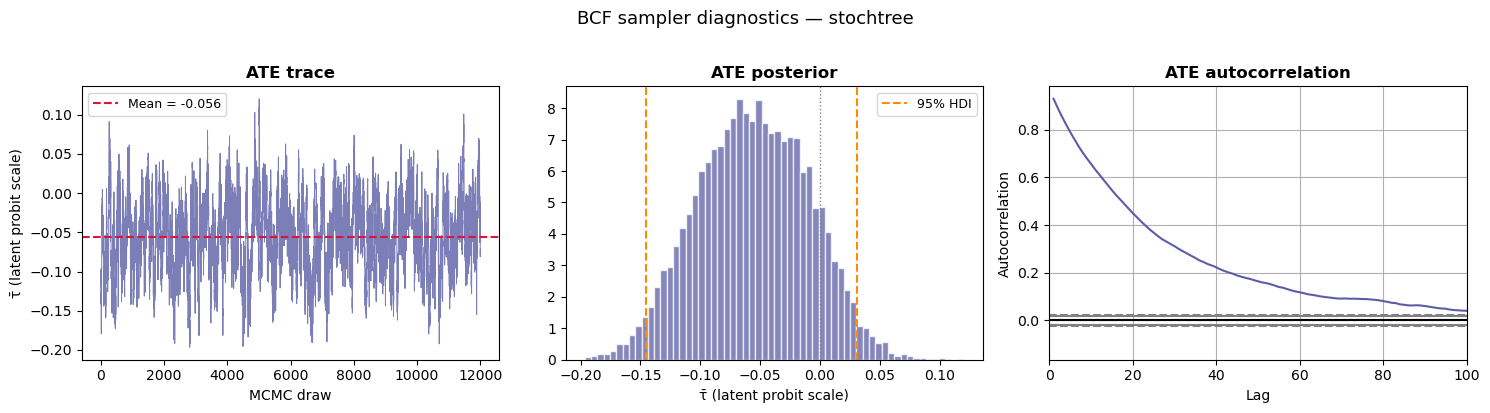

In [ ]:
ate_trace = tau_draws.mean(axis=0)    # (num_mcmc,) — ATE per draw
att_trace = tau_draws[treated_idx].mean(axis=0)
 
# FIX: pass 1-D array to az.ess/az.hdi directly (not wrapped in newaxis)
ate_ess = float(az.ess(ate_trace))
att_ess = float(az.ess(att_trace))
ate_rhat = float(az.rhat(ate_trace))
att_rhat = float(az.rhat(att_trace))

# Print Rhat and ESS for ATE and ATT 
print(f"\nATE ESS: {ate_ess:.0f} / {len(ate_trace)} draws")
print(f"ATT ESS: {att_ess:.0f} / {len(att_trace)} draws")
print(f"ATE Rhat: {ate_rhat:.3f}")
print(f"ATT Rhat: {att_rhat:.3f}")
if ate_ess < 200:
    print("  WARNING: ESS < 200 — consider increasing num_gfr or num_mcmc")

 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
axes[0].plot(ate_trace, lw=0.7, color="#5B5EA6", alpha=0.8)
axes[0].axhline(ate_trace.mean(), color="crimson", lw=1.5, linestyle="--",
                label=f"Mean = {ate_trace.mean():.3f}")
axes[0].set_title("ATE trace", fontweight="bold")
axes[0].set_xlabel("MCMC draw")
axes[0].set_ylabel("τ̄ (latent probit scale)")
axes[0].legend(fontsize=9)
 
axes[1].hist(ate_trace, bins=60, color="#5B5EA6", alpha=0.75, density=True, edgecolor="white")
axes[1].axvline(0, color="gray", lw=1, linestyle=":")
# FIX: call az.hdi on 1-D array
hdi_95 = az.hdi(ate_trace, hdi_prob=0.95)
axes[1].axvline(hdi_95[0], color="darkorange", lw=1.5, linestyle="--", label="95% HDI")
axes[1].axvline(hdi_95[1], color="darkorange", lw=1.5, linestyle="--")
axes[1].set_title("ATE posterior", fontweight="bold")
axes[1].set_xlabel("τ̄ (latent probit scale)")
axes[1].legend(fontsize=9)
 
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(pd.Series(ate_trace), ax=axes[2], color="#5B5EA6")
axes[2].set_xlim(0, 100)
axes[2].set_title("ATE autocorrelation", fontweight="bold")
 
fig.suptitle("BCF sampler diagnostics — stochtree", fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig(f"{output_folder}bcf_{dx_name}_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Posterior Predictive Check

`yhat_draws` gives posterior draws of $\hat{P}(Y_i=1)$ on the probability scale. We compare the distribution of predicted probabilities against the observed event rate and simulate binary outcomes to check calibration.

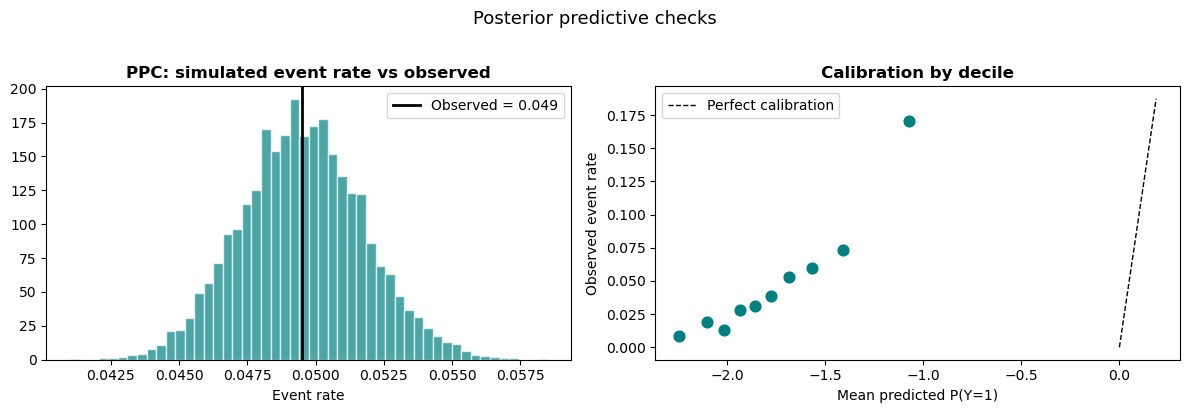

Observed event rate    : 0.0495
PPC mean event rate    : 0.0495
PPC 95% interval       : [0.0452, 0.0542]


In [ ]:
# Simulate binary posterior predictive draws given yhat (min=-3.92, max=1.53)
ppc_p_draws   = norm.cdf(yhat_draws)          # (N, num_mcmc) — probabilities
ppc_bin_draws = rng.binomial(1, ppc_p_draws)  # (N, num_mcmc) — binary draws
ppc_event_rates = ppc_bin_draws.mean(axis=0)  # per-draw event rate
obs_rate        = y_data.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: PPC event rate vs observed
axes[0].hist(ppc_event_rates, bins=50, color="teal", alpha=0.7, density=True, edgecolor="white")
axes[0].axvline(obs_rate, color="black", lw=2, label=f"Observed = {obs_rate:.3f}")
axes[0].set_xlabel("Event rate")
axes[0].set_title("PPC: simulated event rate vs observed", fontweight="bold")
axes[0].legend()

# Right: mean predicted P(Y=1) by observed outcome
pred_prob = yhat_mean
df_cal = pd.DataFrame({"pred": pred_prob, "obs": y_data.astype(int), "T": T})
df_cal["decile"] = pd.qcut(df_cal["pred"], 10, labels=False, duplicates="drop")
cal_summary = df_cal.groupby("decile").agg(pred_mean=("pred", "mean"), obs_mean=("obs", "mean")).reset_index()

axes[1].scatter(cal_summary["pred_mean"], cal_summary["obs_mean"], color="teal", s=60, zorder=3)
lims = [0, max(cal_summary["pred_mean"].max(), cal_summary["obs_mean"].max()) * 1.1]
axes[1].plot(lims, lims, "k--", lw=1, label="Perfect calibration")
axes[1].set_xlabel("Mean predicted P(Y=1)")
axes[1].set_ylabel("Observed event rate")
axes[1].set_title("Calibration by decile", fontweight="bold")
axes[1].legend()

fig.suptitle("Posterior predictive checks", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print(f"Observed event rate    : {obs_rate:.4f}")
print(f"PPC mean event rate    : {ppc_event_rates.mean():.4f}")
print(f"PPC 95% interval       : [{np.percentile(ppc_event_rates, 2.5):.4f}, {np.percentile(ppc_event_rates, 97.5):.4f}]")

## 7. ATE and ATT

Treatment effects are on the **latent probit scale**. To convert to an interpretable absolute risk difference, we compute the counterfactual predicted probabilities:

$$\text{Risk difference}_i = \Phi(\mu_i + \tau_i) - \Phi(\mu_i)$$

This is the marginal effect of treatment for individual $i$, averaging over the posterior. Note this is person-specific because the probit link is nonlinear — a given $\tau$ on the latent scale translates to different risk differences depending on where $\mu_i$ sits on the probit curve.

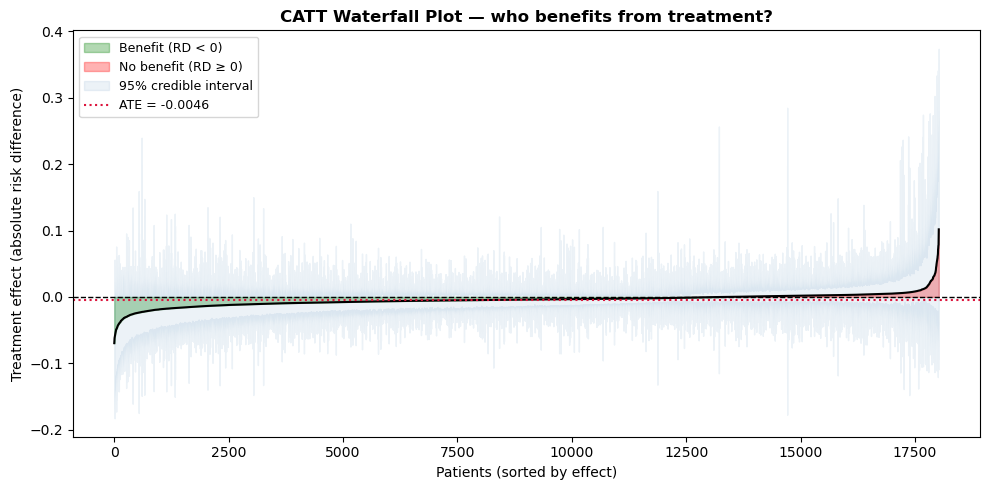

Proportion with estimated benefit (RD < 0): 73.9%


In [ ]:
ird_lo95  = np.percentile(rd_draws, 2.5,  axis=1)
ird_hi95  = np.percentile(rd_draws, 97.5, axis=1)
 
sort_idx      = np.argsort(ird_mean)
ird_sorted    = ird_mean[sort_idx]
ird_lo_sorted = ird_lo95[sort_idx]
ird_hi_sorted = ird_hi95[sort_idx]
xs = np.arange(len(ird_sorted))
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(xs, 0, ird_sorted, where=(ird_sorted < 0), color="green", alpha=0.3,
                label="Benefit (RD < 0)")
ax.fill_between(xs, 0, ird_sorted, where=(ird_sorted >= 0), color="red", alpha=0.3,
                label="No benefit (RD ≥ 0)")
ax.plot(xs, ird_sorted, color="black", lw=1.5)
ax.fill_between(xs, ird_lo_sorted, ird_hi_sorted, alpha=0.1, color="steelblue",
                label="95% credible interval")
ax.axhline(0, color="black", linestyle="--", lw=1)
ax.axhline(ird_mean.mean(), color="crimson", linestyle=":", lw=1.5,
           label=f"ATE = {ird_mean.mean():.4f}")
ax.set_ylabel("Treatment effect (absolute risk difference)")
ax.set_xlabel("Patients (sorted by effect)")
ax.set_title("CATT Waterfall Plot — who benefits from treatment?", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig(f"{output_folder}bcf_{dx_name}_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
 
pct_benefit = (ird_mean < 0).mean()
print(f"Proportion with estimated benefit (RD < 0): {pct_benefit:.1%}")

## 10. Credible-Interval Caterpillar Plot (sorted by τ)

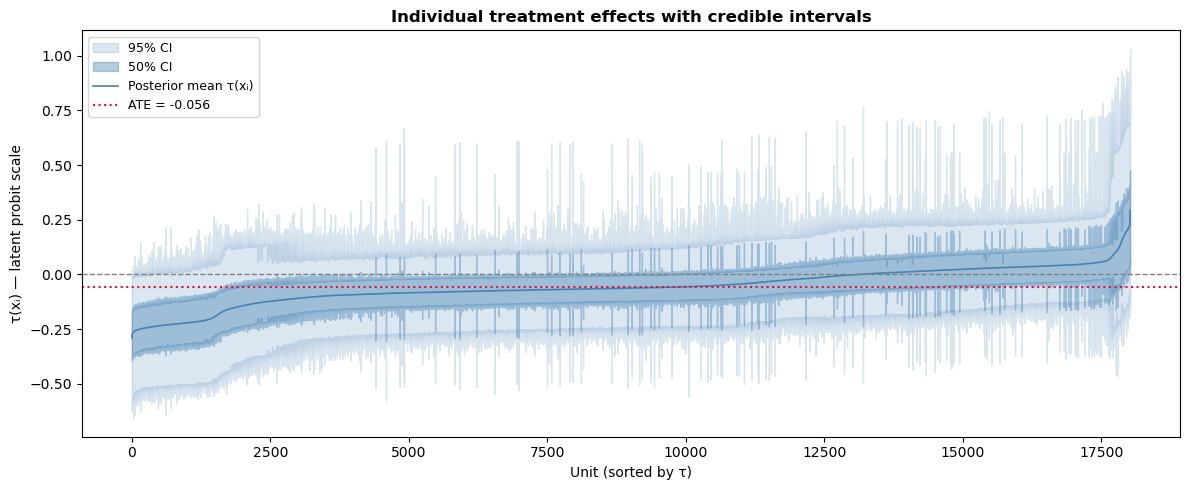

In [ ]:
tau_lo50 = np.percentile(tau_draws, 25,  axis=1)
tau_hi50 = np.percentile(tau_draws, 75,  axis=1)
 
sort_idx_tau = np.argsort(tau_mean)
xs = np.arange(len(tau_mean))
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(xs, tau_lo95[sort_idx_tau], tau_hi95[sort_idx_tau],
                alpha=0.2, color="steelblue", label="95% CI")
ax.fill_between(xs, tau_lo50[sort_idx_tau], tau_hi50[sort_idx_tau],
                alpha=0.4, color="steelblue", label="50% CI")
ax.plot(xs, tau_mean[sort_idx_tau], lw=1.2, color="steelblue",
        label="Posterior mean τ(xᵢ)")
ax.axhline(0, color="gray", lw=1, linestyle="--")
ax.axhline(tau_mean.mean(), color="crimson", lw=1.5, linestyle=":",
           label=f"ATE = {tau_mean.mean():.3f}")
ax.set_xlabel("Unit (sorted by τ)")
ax.set_ylabel("τ(xᵢ) — latent probit scale")
ax.set_title("Individual treatment effects with credible intervals", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig(f"{output_folder}bcf_{dx_name}_caterpillar.png", dpi=150, bbox_inches="tight")
plt.show()